# Analysis: scaling law and intrinsic dimension

Analysis of the results produced by `scaling_law_experiment.ipynb`. Loads the `results.npz`
files for each latent dimension, fits the exponent by two different procedures, and compares
which measure of dimension (the imposed latent one or the intrinsic one measured on the
activations) better predicts that exponent.

This notebook **requires no retraining**: the `results.npz` files in the repository are
enough.

## 1. Loading results and fitting the exponent

For each latent dimension, `results.npz` is read and $L(N) = C_0 + C_1 N^{-\alpha}$ is
fitted with `curve_fit`.

The upper bound on $C_0$ is set to `L.min() * 0.99` to force it strictly below the smallest
observed value, since the exponential growth contribution is strictly positive. 

**This is the only place where $\alpha$ is fitted.** Everything downstream reuses the value
stored in `results[d]["alpha"]`, so the exponents in the figures and those in the
regressions are always the same numbers.

In [2]:
import numpy as np
import tensorflow as tf
from pathlib import Path
from scipy.optimize import curve_fit

# ────────────────────────────────────────────────────────────────────────
# Paths
# ────────────────────────────────────────────────────────────────────────
REPO_ROOT  = Path(".").resolve()           # run from the repository root
MODEL_ROOT = REPO_ROOT / "models_std4_train"          # where d*/ and results.npz live

# ────────────────────────────────────────────────────────────────────────
# Power-law form (same as before)
# ────────────────────────────────────────────────────────────────────────
def power_law_with_floor(N, C0, C1, alpha):
    alpha = np.clip(alpha, -10, 10)
    return C0 + C1 * N ** (-alpha)

# ────────────────────────────────────────────────────────────────────────
# Data structures in RAM
# ────────────────────────────────────────────────────────────────────────
students = {}   # students[d][w] = loaded Keras model
alphas   = {}   # alphas[d]     = fitted alpha for that latent dimension
results  = {}   # results[d]    = dict with N_vals, L_vals, etc.

d_intrinsic_S={}
d_intrinsic_T={}

# ────────────────────────────────────────────────────────────────────────
# Load all latent-dimension folders: models/d2, models/d4, ...
# ────────────────────────────────────────────────────────────────────────
for d_dir in sorted(MODEL_ROOT.glob("d*")):
    if not d_dir.is_dir():
        continue

    # Parse d from folder name 'd4' -> 4
    try:
        d_latent = int(d_dir.name[1:])
    except ValueError:
        continue

    print(f"\n=== Loading models and data for d = {d_latent} from {d_dir} ===")

    # ────────────────────────────────────────────────────────────────────────
    # 1. Load numeric results (N, L, etc.) and recompute alpha
    # ────────────────────────────────────────────────────────────────────────
    res_path = d_dir / "results.npz"
    if not res_path.exists():
        print(f"  ⚠ No results.npz in {d_dir}, skipping.")
        continue

    data   = np.load(res_path)
    N_vals = data["N_vals"].astype(float)
    L_vals = data["L_vals"].astype(float)
    d_intrinsic_S[d_latent] = data["d_intrinsic_S"].astype(float)
    d_intrinsic_T[d_latent] = data["d_intrinsic_T"].astype(float)

    # Initial guesses (robust but simple)
    p0 = [L_vals.min() * 0.95, L_vals.max() - L_vals.min(), 1.0]

    try:
        popt, _ = curve_fit(
            power_law_with_floor, N_vals, L_vals, p0=p0,
            bounds=([0, 0, 0], [L_vals.min() * 0.99, np.inf, 10]),
            maxfev=10_000,
        )
        C0_est, C1_est, alpha_est = popt
    except RuntimeError:
        print("  ⚠ curve_fit did not converge; setting alpha = NaN.")
        C0_est, C1_est, alpha_est = np.nan, np.nan, np.nan

    alphas[d_latent] = alpha_est
    results[d_latent] = {
        "N_vals":   N_vals,         # Parameter counts
        "L_vals":   L_vals,         # Test MSE values
        "C0":       C0_est,         # Fitted C0
        "C1":       C1_est,         # Fitted C1
        "alpha":    alpha_est,      # Fitted alpha
    }

    print(f"  → alpha(d={d_latent}) = {alpha_est:.4f}")

    # ────────────────────────────────────────────────────────────────────────
    # 2. Load all student models for this d into RAM
    # ────────────────────────────────────────────────────────────────────────
    students[d_latent] = {}
    for model_path in sorted(d_dir.glob("student_w*.keras")):
        # Extract width from filename student_w{w}.keras
        # e.g. "student_w64.keras" -> w = 64
        stem = model_path.stem            # "student_w64"
        try:
            w_str = stem.split("w", 1)[1]
            width = int(w_str)
        except (IndexError, ValueError):
            print(f"  ⚠ Could not parse width from {model_path.name}, skipping.")
            continue

        print(f"  Loading model: d={d_latent}, width={width}")
        model = tf.keras.models.load_model(model_path)
        students[d_latent][width] = model

print("\n=== Done. All alphas and models are now in RAM. ===")


=== Loading models and data for d = 10 from C:\Users\Priet005\OneDrive - Universiteit Utrecht\Documents\My repo\ML and information theory\Error vs dimension\models_std4_train\d10 ===
  → alpha(d=10) = 0.7738
  Loading model: d=10, width=10
  Loading model: d=10, width=12
  Loading model: d=10, width=128
  Loading model: d=10, width=16
  Loading model: d=10, width=168
  Loading model: d=10, width=18
  Loading model: d=10, width=20
  Loading model: d=10, width=24
  Loading model: d=10, width=28
  Loading model: d=10, width=32
  Loading model: d=10, width=36
  Loading model: d=10, width=40
  Loading model: d=10, width=46
  Loading model: d=10, width=52
  Loading model: d=10, width=58
  Loading model: d=10, width=64
  Loading model: d=10, width=72
  Loading model: d=10, width=8
  Loading model: d=10, width=80
  Loading model: d=10, width=96

=== Loading models and data for d = 12 from C:\Users\Priet005\OneDrive - Universiteit Utrecht\Documents\My repo\ML and information theory\Error vs di

## 2. Fitted exponent against the $4/d$ prediction

One panel per latent dimension, showing the excess loss $L - C_0$ against parameter count on
log-log axes, with the fitted line.

The $d = 2$ panel is anomalous and should be read with care: training reaches the Bayes
error at nearly every width, $C_0$ absorbs virtually all of the loss, and what remains as
excess is noise. The fitted line does not describe the points. That case is excluded from
the regressions in section 4 onwards.

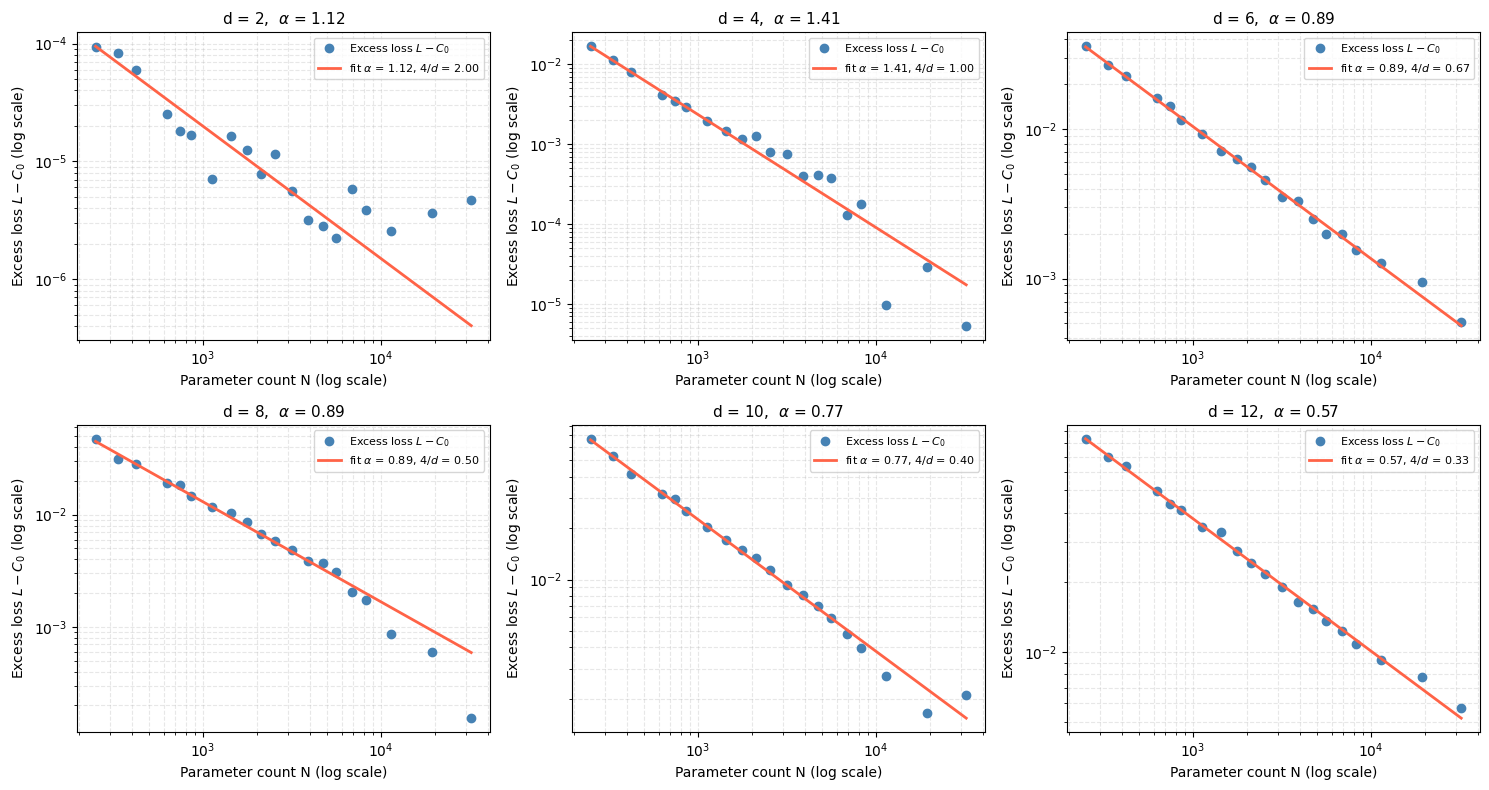

In [3]:
# ---------------------------------------------------------------------
# Curve fit to the predicted law L(N) = C0 + C1 * N^(-alpha)
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("output", exist_ok=True)


dims = sorted(results.keys())
n_dims = len(dims)

n_cols = min(3, n_dims)
n_rows = int(np.ceil(n_dims / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

panels = [(idx, d) for idx, d in enumerate(dims) if d >= 2]

for idx, d in panels:
    row = idx // n_cols
    col = idx % n_cols
    ax  = axes[row][col]

    r        = results[d]
    N        = r["N_vals"]
    L        = r["L_vals"]
    alpha_th = 4.0 / d

# ── Reuse the fit from the previous cell (no refitting here) ──

    C0_est, C1_est, alpha_est = r["C0"], r["C1"], r["alpha"]

# ── Plot: data and fitted line using linear-regression alpha ─

    ax.loglog(N, L-C0_est, "o", color="steelblue", ms=6,
              label="Excess loss $L - C_0$")

    N_fit  = np.linspace(N.min(), N.max(), 200)
    ex_fit = C1_est * N_fit ** (-alpha_est)
    ax.loglog(N_fit, ex_fit, "-", color="tomato", lw=2,
              label=rf"fit $\alpha$ = {alpha_est:.2f}, $4/d$ = {alpha_th:.2f}")

    ax.set_title(rf"d = {d},  $\alpha$ = {alpha_est:.2f}", fontsize=11)
    ax.set_xlabel("Parameter count N (log scale)")
    ax.set_ylabel(r"Excess loss $L - C_0$ (log scale)")
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.legend(fontsize=8, loc="best")

# Hide unused subplots
for j in range(idx + 1, n_rows * n_cols):
    row = j // n_cols
    col = j % n_cols
    axes[row][col].axis("off")

plt.tight_layout()
plt.show()

# ── Save figure 1 ──────────────────────────────
fig.savefig("output/scaling_law_fits.pdf", bbox_inches="tight")

plt.show()

## 3. Which dimension predicts the exponent?

The paper's prediction, $\alpha \approx 4/d$, is equivalent to $d$ being linear in
$1/\alpha$ with slope 4. Two quantities are regressed against $1/\alpha$ here: the latent
dimension imposed by construction, and the intrinsic dimension measured on the activations
of the widest student.

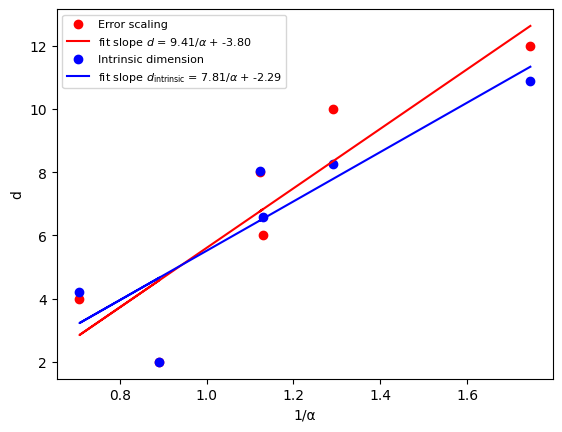

In [5]:
# ─────────────────────────────────────────────
# Regression of d (computed with linear regression) and intrinsic dimension (computed with MLE (Levina-Bickel) intrinsic dimension estimator) vs 1/alpha
# ─────────────────────────────────────────────
dims = np.array(dims, dtype=float)
d_intrinsic_S_ref = np.array([d_intrinsic_S[d] for d in dims], dtype=float)[:,-1]

# Use the new alpha estimates from linear regression
d_alpha_list = np.array([1.0 / results[d]["alpha"] for d in dims], dtype=float)

m_d,  b_d  = np.polyfit(d_alpha_list, dims, 1)
m_ID, b_ID = np.polyfit(d_alpha_list, d_intrinsic_S_ref, 1)

dim_pred_d  = m_d  * d_alpha_list + b_d
dim_pred_ID = m_ID * d_alpha_list + b_ID

fig2 = plt.figure()
plt.scatter(d_alpha_list, dims, color="red", label="Error scaling")
plt.plot(d_alpha_list, dim_pred_d, color="red",
         label=rf"fit slope $d$ = {m_d:.2f}/$\alpha$ + {b_d:.2f}")
plt.scatter(d_alpha_list, d_intrinsic_S_ref, color="blue", label="Intrinsic dimension")
plt.plot(d_alpha_list, dim_pred_ID, color="blue",
         label=rf"fit slope $d_{{\text{{intrinsic}}}}$ = {m_ID:.2f}/$\alpha$ + {b_ID:.2f}")
plt.xlabel("1/α")
plt.ylabel("d")
plt.legend(fontsize=8, loc="best")

# ── Save figure 2 ──────────────────────────────
fig2.savefig("output/dimension_regression.pdf", bbox_inches="tight")

plt.show()

## 4. Comparing fitting procedures on a single case

`curve_fit` on $C_0 + C_1 N^{-\alpha}$ versus a log-log linear regression that ignores $C_0$.

The `interval_b = -3` trim discards the three largest-$N$ points: in the tail, the excess
loss is of the order of the training noise and drags the log-log fit, which has no constant
term to absorb it. The same trim is applied to every dimension.

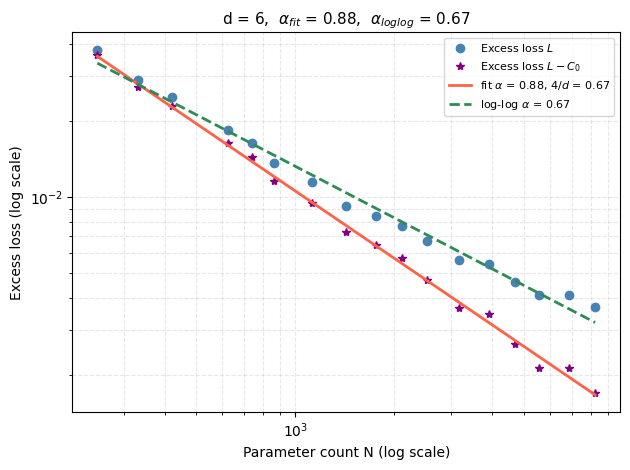

In [8]:
# ---------------------------------------------------------------------
# Case by case analysis with two different fit procedures: curve_fit and log-log linear regression
# For log-log we ignore the C0 term and fit log(L) = log(C1) - alpha * log(N), we remove the tail of the curve 
# where the loss is very small and dominated by noise, and we compare the two estimates of alpha.
# ---------------------------------------------------------------------


d_sample = 6

interval_a = 0
interval_b = -3

r        = results[d_sample]
N        = r["N_vals"][interval_a:interval_b]
L        = r["L_vals"][interval_a:interval_b]
alpha_th = 4.0 / d_sample


       # ── Scaling law fit ────────────────────────


p0 = [r["L_vals"].min(), 1, 1]


try:
    popt, _ = curve_fit(
                power_law_with_floor, N, L, p0=p0,
                bounds=([0, 0, 0], [np.inf , np.inf, 10]),
                maxfev=10_000,
            )
    C0_est, C1_est, alpha_est = popt
except RuntimeError:
    print("  ⚠  curve_fit did not converge; storing NaNs.")
    C0_est, C1_est, alpha_est = np.nan, np.nan, np.nan


# ── Log-log linear regression estimate of alpha using L - C0 ─
excess = L
mask = excess > 0          # guard against negative/zero excess from noise
slope, intercept = np.polyfit(np.log(N[mask]), np.log(excess[mask]), 1)
alpha_loglog = -slope


# ── Plot: data and fitted line using linear-regression alpha ─
plt.loglog(N, L, "o", color="steelblue", ms=6,
            label="Excess loss $L$")
plt.loglog(N, L-C0_est, "*", color="purple", ms=6,
            label="Excess loss $L-C_0$")


N_fit  = np.linspace(N.min(), N.max(), 200)
ex_fit = C1_est * N_fit ** (-alpha_est)
plt.loglog(N_fit, ex_fit, "-", color="tomato", lw=2,
             label=rf"fit $\alpha$ = {alpha_est:.2f}, $4/d$ = {alpha_th:.2f}")

loglog_fit = np.exp(intercept) * N_fit ** (-alpha_loglog)
plt.loglog(N_fit, loglog_fit, "--", color="seagreen", lw=2,
            label=rf"log-log $\alpha$ = {alpha_loglog:.2f}")


plt.title(rf"d = {d_sample},  $\alpha_{{fit}}$ = {alpha_est:.2f},  $\alpha_{{loglog}}$ = {alpha_loglog:.2f}", fontsize=11)
plt.xlabel("Parameter count N (log scale)")
plt.ylabel(r"Excess loss (log scale)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=8, loc="best")



plt.tight_layout()
plt.show()

## 5. Regression using the log-log exponents

The section 3 analysis is repeated with exponents obtained by log-log regression, excluding
$d = 2$ for the reason given above.

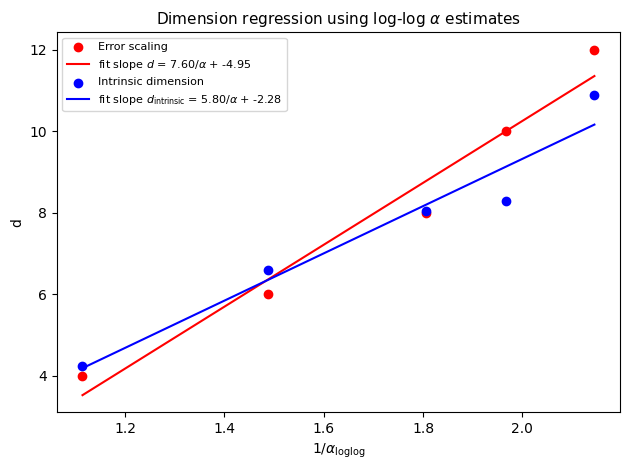

{4: np.float64(0.8973876429418741), 6: np.float64(0.6721723966574916), 8: np.float64(0.5538282866599671), 10: np.float64(0.5082410580888935), 12: np.float64(0.46619097015023103)}


In [9]:
# ---------------------------------------------------------------------
# Compute log-log alpha for each d, then regress
# d (linear regression target) and intrinsic dimension (MLE Levina-Bickel)
# against 1/alpha_loglog
# We remove the d=2 case, because there the C0 term is very significant. In this case, the learning routine rapidly reaches the bayesian error for many of the widths, and hence the log-log fit with no C0 is not reliable.
# ---------------------------------------------------------------------


interval_a = 0
interval_b = -3   # same tail-trimming as your single-case analysis

dims = sorted(results.keys())
dims=dims[1:]

alpha_loglog_dict = {}

for d in dims:
    r = results[d]
    N = r["N_vals"][interval_a:interval_b]
    L = r["L_vals"][interval_a:interval_b]

    excess = L  # C0 ignored, as in your log-log procedure
    mask = excess > 0  # guard against negative/zero excess from noise

    slope, intercept = np.polyfit(np.log(N[mask]), np.log(excess[mask]), 1)
    alpha_loglog_dict[d] = -slope

# ── Build arrays for regression ────────────────
dims_arr = np.array(dims, dtype=float)
d_intrinsic_S_ref = np.array([d_intrinsic_S[d] for d in dims], dtype=float)[:, -1]

d_alpha_loglog_list = np.array([1.0 / alpha_loglog_dict[d] for d in dims], dtype=float)

m_d,  b_d  = np.polyfit(d_alpha_loglog_list, dims_arr, 1)
m_ID, b_ID = np.polyfit(d_alpha_loglog_list, d_intrinsic_S_ref, 1)

dim_pred_d  = m_d  * d_alpha_loglog_list + b_d
dim_pred_ID = m_ID * d_alpha_loglog_list + b_ID

# ── Plot ────────────────────────────────────────
fig3 = plt.figure()

plt.scatter(d_alpha_loglog_list, dims_arr, color="red", label="Error scaling")
plt.plot(d_alpha_loglog_list, dim_pred_d, color="red",
         label=rf"fit slope $d$ = {m_d:.2f}/$\alpha$ + {b_d:.2f}")

plt.scatter(d_alpha_loglog_list, d_intrinsic_S_ref, color="blue", label="Intrinsic dimension")
plt.plot(d_alpha_loglog_list, dim_pred_ID, color="blue",
         label=rf"fit slope $d_{{\text{{intrinsic}}}}$ = {m_ID:.2f}/$\alpha$ + {b_ID:.2f}")

plt.xlabel(r"$1/\alpha_{\text{loglog}}$")
plt.ylabel("d")
plt.title("Dimension regression using log-log $\\alpha$ estimates", fontsize=11)
plt.legend(fontsize=8, loc="best")
plt.tight_layout()

# ── Save figure ──────────────────────────────────
fig3.savefig("output/dimension_regression_loglog_alpha.png", dpi=300, bbox_inches="tight")
fig3.savefig("output/dimension_regression_loglog_alpha.pdf", bbox_inches="tight")

plt.show()

print(alpha_loglog_dict)

## 6. Results

**The analysis reproduces the power law reproduces but fails to accurately capture the coefficient.** The exponent falls monotonically
with latent dimension, as the paper predicts, but its value is systematically above $4/d$ —
by a factor of 1.3 to 1.9 — and the gap widens with $d$. In terms of the regressions, the
slope of $d$ against $1/\alpha$ comes out at 9.41 with `curve_fit` and 7.60 with log-log,
against the predicted 4.

**Intrinsic dimension predicts better than latent dimension.** This is one of the main results and it holds under both fitting procedures: the slope drops from 9.41 to
7.81 with `curve_fit`, and from 7.60 to 5.80 with log-log. The effective dimension of the
internal representation sits closer to the theoretical relation than the dimension imposed
by construction, though both remain above 4.

This is consistent with the measured values themselves: intrinsic dimension saturates below
the latent one as $d$ grows (roughly 10.9 against 12), suggesting the network never resolves
every direction of the latent space, and that the exponent responds to that smaller
effective dimension.

The fitting process is very unstable. Removing the C0 parameter and restricting the fit to a region where its contribution is negligible combined with the use of the intrinsic dimension provides the best results (5.80).

**Limitations.** The exponents heavily depend on the fitting procedure and the treatment of $C_0$ is delicate at low dimension. For higher dimensions, longer training would reduce the noise in the large-$N$ tail, which is where the two methods disagree most.